In [1]:
!pip install gymnasium
!pip install matplotlib

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

In [4]:
env = gym.make("Blackjack-v1")

print("Blackjack Environment Created")

Blackjack Environment Created


In [5]:
state, info = env.reset()

print("Initial State:", state)

Initial State: (16, 4, 0)


In [6]:
def policy(state):

    player_sum, dealer_card, usable_ace = state

    if player_sum >= 20:
        return 0
    else:
        return 1

In [7]:
state, info = env.reset()

done = False

while not done:

    action = policy(state)

    next_state, reward, terminated, truncated, info = env.step(action)

    print("State:", state)
    print("Action:", action)
    print("Reward:", reward)

    state = next_state

    done = terminated or truncated

print("Episode Finished")

State: (20, 7, 0)
Action: 0
Reward: 1.0
Episode Finished


In [8]:
returns_sum = defaultdict(float)

returns_count = defaultdict(float)

V = defaultdict(float)

In [9]:
episodes = 50000

for episode in range(episodes):

    episode_memory = []

    state, info = env.reset()

    done = False

    while not done:

        action = policy(state)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode_memory.append((state, reward))

        state = next_state

        done = terminated or truncated

    G = 0

    visited_states = set()

    for state, reward in reversed(episode_memory):

        G += reward

        if state not in visited_states:

            returns_sum[state] += G

            returns_count[state] += 1

            V[state] = (
                returns_sum[state] /
                returns_count[state]
            )

            visited_states.add(state)

print("Training Complete")

Training Complete


In [10]:
for i, (state, value) in enumerate(V.items()):

    print(state, ":", round(value, 2))

    if i > 10:
        break


(15, 10, 0) : -0.65
(14, 10, 0) : -0.63
(18, 1, 0) : -0.76
(12, 1, 0) : -0.66
(18, 10, 0) : -0.7
(12, 10, 0) : -0.55
(12, 10, 1) : -0.3
(14, 9, 0) : -0.64
(14, 2, 0) : -0.62
(20, 3, 0) : 0.67
(19, 3, 0) : -0.72
(19, 3, 1) : -0.56


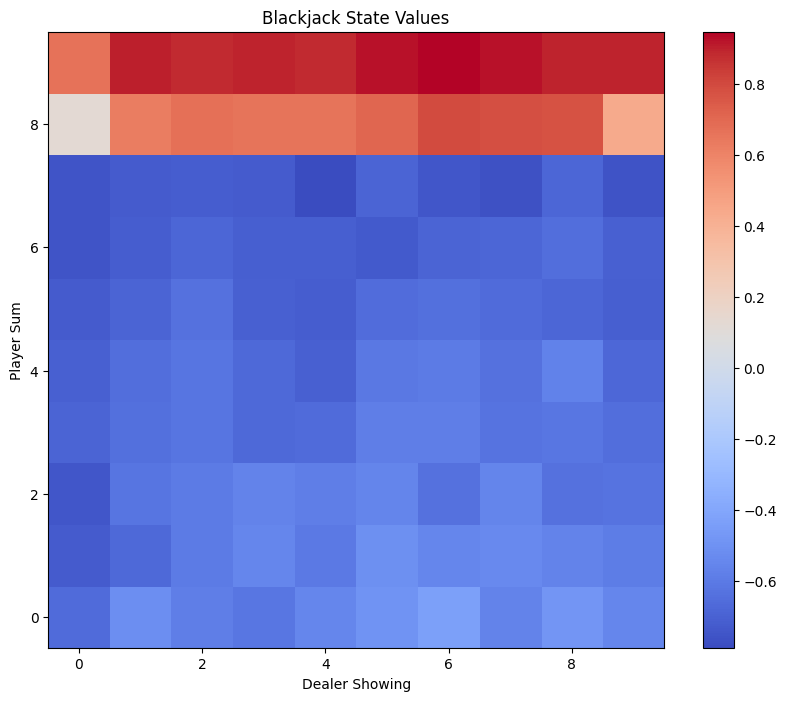

In [11]:
player_range = range(12, 22)
dealer_range = range(1, 11)

grid = np.zeros((10,10))

for i, player in enumerate(player_range):

    for j, dealer in enumerate(dealer_range):

        state = (player, dealer, False)

        grid[i,j] = V[state]

plt.figure(figsize=(10,8))

plt.imshow(grid, cmap='coolwarm', origin='lower')

plt.colorbar()

plt.xlabel("Dealer Showing")

plt.ylabel("Player Sum")

plt.title("Blackjack State Values")

plt.show()